In [1]:
import cuml

from cuml.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

import sklearn

import matplotlib.pyplot as plt

import xgboost as xgb
import lightgbm as lgb

import torch

import numpy as np
import cupy as cp

import pandas as pd
from pathlib import Path
import gc

In [2]:
# RF

RF = {
    "model": RandomForestRegressor,
    "n_estimators": [50, 50, 50],
    "max_depth": [20, 21, 1],
    "n_bins": [128, 256, 2],
    "max_features": [1.0, 1.0, 0.1],
    "results": []
}

In [3]:
# ET

ET = {
    "model": ExtraTreesRegressor,
    "n_estimators": [50, 50, 50],
    "max_depth": [21, 21, 1],
    "min_samples_leaf": [4, 4, 2],
    "max_features": [1.0, 1.0, 0.1],
    "results": []
}

In [4]:
datasetPath = Path("/home/philipm/Desktop/ML-For-CV-Robustness/datasets/datasetGTCombined.csv")

#making sure
datasetPath.is_file()

True

In [5]:
dataset = pd.read_csv(datasetPath)
dataset.head()

,grviIn,meanRefR,meanRefG,illumR,illumG,blockIdx,sunRoll,sunPitch,sunYaw,camRoll,camPitch,camYaw,grviOut
0,0.163549,0.000324,0.000421,1130.973355,1020.232214,0.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0,0.2
1,0.097110,0.000412,0.000486,1130.973355,1020.232214,1.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0,0.2
2,0.074345,0.000448,0.000517,1130.973355,1020.232214,2.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0,0.2
3,0.156574,0.000374,0.000481,1130.973355,1020.232214,3.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0,0.2
4,0.116627,0.000393,0.000479,1130.973355,1020.232214,4.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0,0.2


In [6]:
target_col = dataset["grviOut"]
labels = target_col.to_numpy(dtype="float32")
labels

array([0.2 , 0.2 , 0.2 , ..., 0.26, 0.26, 0.26],
      shape=(667240,), dtype=float32)

In [7]:
inputs = dataset.drop("grviOut", axis=1)
inputs.head()

,grviIn,meanRefR,meanRefG,illumR,illumG,blockIdx,sunRoll,sunPitch,sunYaw,camRoll,camPitch,camYaw
0,0.163549,0.000324,0.000421,1130.973355,1020.232214,0.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0
1,0.097110,0.000412,0.000486,1130.973355,1020.232214,1.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0
2,0.074345,0.000448,0.000517,1130.973355,1020.232214,2.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0
3,0.156574,0.000374,0.000481,1130.973355,1020.232214,3.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0
4,0.116627,0.000393,0.000479,1130.973355,1020.232214,4.0,180.0,-63.812729,-56.07412,0.0,-19.258,-0.0


In [8]:
inputs = inputs.to_numpy(dtype="float32")
inputs

array([[ 1.6354947e-01,  3.2419228e-04,  4.2050949e-04, ...,
         0.0000000e+00, -1.9257999e+01, -0.0000000e+00],
       [ 9.7109884e-02,  4.1166358e-04,  4.8633927e-04, ...,
         0.0000000e+00, -1.9257999e+01, -0.0000000e+00],
       [ 7.4344695e-02,  4.4785510e-04,  5.1731960e-04, ...,
         0.0000000e+00, -1.9257999e+01, -0.0000000e+00],
       ...,
       [ 2.8367174e-01,  2.6904649e-04,  4.2221454e-04, ...,
        -0.0000000e+00, -2.2218000e+01, -1.8000000e+02],
       [ 2.4132200e-01,  3.4478656e-04,  5.0772808e-04, ...,
        -0.0000000e+00, -2.2218000e+01, -1.8000000e+02],
       [ 2.7499148e-01,  3.2630350e-04,  5.1217148e-04, ...,
        -0.0000000e+00, -2.2218000e+01, -1.8000000e+02]],
      shape=(667240, 12), dtype=float32)

In [9]:
if len(labels) != len (inputs):
    print ("problem")

In [10]:
n_total = len(inputs)

n_train = int(0.8*n_total)
n_val = int(0.2*n_total)

# shuffle
g = torch.Generator().manual_seed(42)
perm = torch.randperm(n_total, generator=g).numpy()

inputs_shuf = inputs[perm]
labels_shuf = labels[perm]

# split
train_inputs, train_labels = inputs_shuf[:n_train], labels_shuf[:n_train]
val_inputs, val_labels = inputs_shuf[n_train:n_train + n_val], labels_shuf[n_train:n_train + n_val]

In [11]:
# scaling
from sklearn.preprocessing import QuantileTransformer, StandardScaler

if False:
    input_scaler = StandardScaler() #QuantileTransformer(output_distribution='normal')
    target_scaler = StandardScaler()

    train_inputs = input_scaler.fit_transform(train_inputs)
    train_labels = target_scaler.fit_transform(train_labels.reshape(-1, 1)).reshape(-1)

    val_inputs = input_scaler.transform(val_inputs)
    val_labels = target_scaler.transform(val_labels.reshape(-1, 1)).reshape(-1)

In [12]:
# RF
# starting point
if False:
    
    ne = RF["n_estimators"][0]
    md = RF["max_depth"][0]
    nb = RF["n_bins"][0]
    mf = RF["max_features"][0]
    
    while True:
        if ne > RF["n_estimators"][1]:
            ne = RF["n_estimators"][0]
            break
    
        while True:
            if md > RF["max_depth"][1]:
                md = RF["max_depth"][0]
                break
    
            while True:
                if nb > RF["n_bins"][1]:
                    nb = RF["n_bins"][0]
                    break
    
                while True:
                    if mf > RF["max_features"][1]:
                        mf = RF["max_features"][0]
                        break
    
                    model = RF["model"](n_estimators=ne, max_depth=md, n_bins=nb, max_features=mf)
                    model.fit(train_inputs, train_labels)
    
                    y_pred = model.predict(val_inputs)
    
                    mse = cuml.metrics.mean_squared_error(val_labels, y_pred)
                    rmse = cp.sqrt(mse)
    
                    RF["results"].append(float(rmse))
    
                    del model
                    gc.collect()
    
                    mf = mf + RF["max_features"][2]
    
                nb = nb * RF["n_bins"][2]
    
            md = md + RF["max_depth"][2]
    
        ne = ne+ RF["n_estimators"][2]

    rel_test_loss = min(RF["results"])*100 / (val_labels.max()-val_labels.min())
    print(str(float(rel_test_loss)) + "%")

    plt.plot(range(len(RF["results"])), RF["results"])
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.show()

In [13]:
# ET
# starting point

if False:

    ne = ET["n_estimators"][0]
    md = ET["max_depth"][0]
    nb = ET["min_samples_leaf"][0]
    mf = ET["max_features"][0]
    
    while True:
        if ne > ET["n_estimators"][1]:
            ne = ET["n_estimators"][0]
            break
    
        while True:
            if md > ET["max_depth"][1]:
                md = ET["max_depth"][0]
                break
    
            while True:
                if nb > ET["min_samples_leaf"][1]:
                    nb = ET["min_samples_leaf"][0]
                    break
    
                while True:
                    if mf > ET["max_features"][1]:
                        mf = ET["max_features"][0]
                        break
    
                    model = ET["model"](n_estimators=ne, max_depth=md, min_samples_leaf=nb, max_features=mf)
                    model.fit(train_inputs, train_labels)
    
                    y_pred = model.predict(val_inputs)
    
                    mse = sklearn.metrics.mean_squared_error(val_labels, y_pred)
                    rmse = np.sqrt(mse)
    
                    ET["results"].append(float(rmse))
    
                    mf = mf + ET["max_features"][2]
    
                nb = nb * ET["min_samples_leaf"][2]
    
            md = md + ET["max_depth"][2]
    
        ne = ne+ ET["n_estimators"][2]
    
        rel_test_loss = min(ET["results"])*100 / (val_labels.max()-val_labels.min())
        print(str(float(rel_test_loss)) + "%")
    
        plt.plot(range(len(ET["results"])), ET["results"])
        plt.xlabel("Index")
        plt.ylabel("Value")
        plt.show()

In [14]:
# make ET fast
from cuml import ForestInference

if False:
    
    y_pred = model.predict(val_inputs)
    
    mse = sklearn.metrics.mean_squared_error(val_labels, y_pred)
    rmse = np.sqrt(mse)
    
    rel_test_loss = rmse*100 / (val_labels.max()-val_labels.min())
    print("unoptimized ET:" + str(float(rel_test_loss)) + "%")


    fil_model = ForestInference.load_from_sklearn(model)

    val_inputs_gpu = cp.asarray(val_inputs, dtype=cp.float32)
    y_pred_gpu = fil_model.predict(val_inputs_gpu)

    mse = cuml.metrics.mean_squared_error(val_labels, y_pred_gpu)
    rmse = cp.sqrt(mse)

    print("optimized ET:" + str(float(rel_test_loss)) + "%")

In [15]:
# XGB

X = {
    "model": xgb,
    "n_estimators": [500, 500, 50],
    "max_depth": [15, 15, 1],
    "min_child_weight": [3, 3, 1],
    "results": []
}

5.6979594230651855%


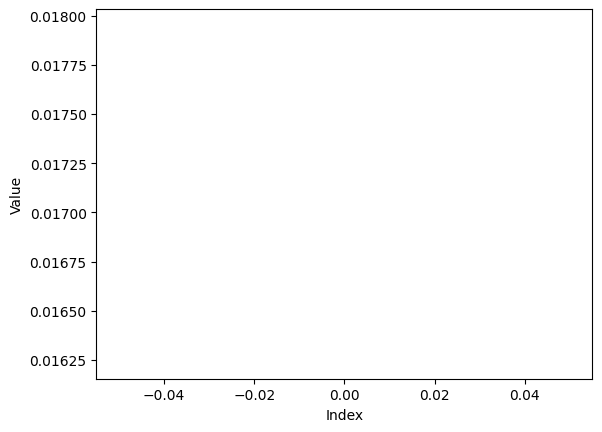

In [16]:
# XGB
# starting point

if True:

    ne = X["n_estimators"][0]
    md = X["max_depth"][0]
    mc = X["min_child_weight"][0]
    
    while True:
        if ne > X["n_estimators"][1]:
            ne = X["n_estimators"][0]
            break
    
        while True:
            if md > X["max_depth"][1]:
                md = X["max_depth"][0]
                break
    
            while True:
                if mc > X["min_child_weight"][1]:
                    mc = X["min_child_weight"][0]
                    break
    
                model = X["model"].XGBRegressor(n_estimators=ne, max_depth=md, min_child_weight=mc, learning_rate=0.05, tree_method="gpu_hist", gpu_id=0)
                model.fit(train_inputs, train_labels)

                y_pred = model.predict(val_inputs)

                mse = sklearn.metrics.mean_squared_error(val_labels, y_pred)
                rmse = np.sqrt(mse)

                X["results"].append(float(rmse))
    
                mc = mc + X["min_child_weight"][2]
    
            md = md + X["max_depth"][2]
    
        ne = ne+ X["n_estimators"][2]
    
        rel_test_loss = min(X["results"])*100 / (val_labels.max()-val_labels.min())
        print(str(float(rel_test_loss)) + "%")
    
        plt.plot(range(len(X["results"])), X["results"])
        plt.xlabel("Index")
        plt.ylabel("Value")
        plt.show()

In [17]:
if True:
    model_path = "best_xgb.json"
    model.save_model(model_path)

    fil_model = ForestInference.load(model_path, model_type="xgboost_json")

    val_inputs_gpu = cp.asarray(val_inputs, dtype=cp.float32)
    y_pred_gpu = fil_model.predict(val_inputs_gpu)

    mse = cuml.metrics.mean_squared_error(val_labels, y_pred_gpu)
    rmse = cp.sqrt(mse)

    print("optimized XGB:" + str(float(rel_test_loss)) + "%")

optimized XGB:5.6979594230651855%
